<h1>Recorrido de Grafos</h1>

Dado un grafo ponderado $(G , w )$ donde $G = (V , E )$ y $w : E  \mapsto \mathbb R$, un
arbol de expansión mı́nima es un arbol de expansión en el que la suma
de los pesos w de las aristas es mı́nima.

<h2>Algoritmo Prim</h2>

El algoritmo de Prim construye un arbol visitando vértices de
manera iterativa hasta que se obtiene un árbol de expansión mı́nima.Se comienza desde un vértice cualquiera y en cada iteración se agrega la arista que tenga el mı́nimo peso y no complete un ciclo.
La complejidad computacional del algoritmo de Prim es $O(V \operatorname{log} V)$.
El siguiente pseudo-código implementa el algoritmo mediante una cola de prioridad:


<img src="https://github.com/sherna90/matematicas_discretas/blob/master/images/algoritmo_prim.png?raw=1" />

<h2>Algoritmo Kruskal</h2>

El algoritmo de Kruskal construye un arbol visitando aristas de
manera iterativa hasta que se obtiene un árbol de expansión mı́nima.
Se comienza desde un vértice cualquiera y en cada iteración se
agrega la arista que tenga el mı́nimo peso y no complete un ciclo.
La complejidad computacional del algoritmo de Kruskal es $O(E \operatorname{log} E)$.


<img src="https://github.com/sherna90/matematicas_discretas/blob/master/images/algoritmo_kruskal.png?raw=1" />

In [1]:
import networkx as nx

G = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
E={(1,2):1,(3,4):2,(2,4):1}
G.add_weighted_edges_from([ (u,v,w) for (u,v),w in E.items()])


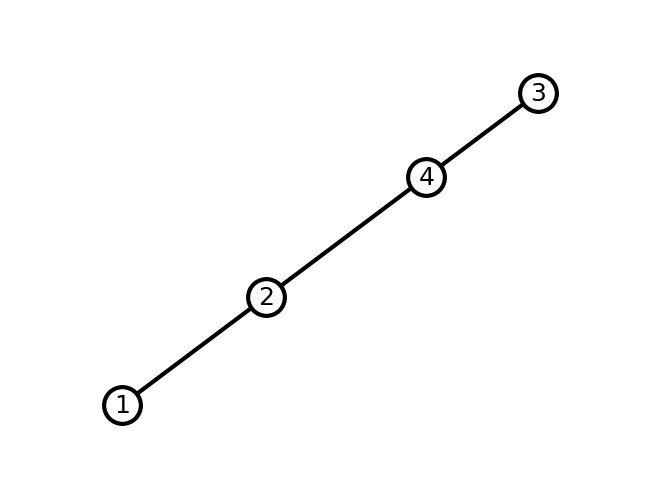

In [2]:
import matplotlib.pyplot as plt

options = {
    "font_size": 18,
    "node_size": 700,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 3,
    "width": 3,
    'with_labels':True
}
nx.draw(G,**options)
ax = plt.gca()
ax.margins(0.20)
plt.axis("off")
plt.show()

In [3]:
T_prim=nx.minimum_spanning_tree(G,algorithm='prim')

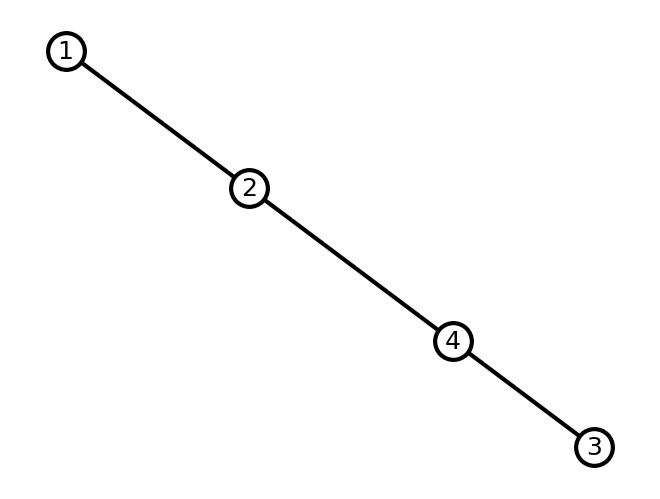

In [4]:
nx.draw(T_prim,**options)

In [5]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

In [6]:
IN_COLAB

False

In [7]:
if IN_COLAB:
    !wget 'https://raw.githubusercontent.com/sherna90/matematicas_discretas/master/data/talca_ciclovias.graphml'
    G_talca=nx.read_graphml('talca_ciclovias.graphml')
else:
    G_talca=nx.read_graphml('data/talca_ciclovias.graphml')

In [8]:
T_talca=nx.minimum_spanning_tree(G_talca.to_undirected(),algorithm='kruskal')

In [13]:
import geopandas as gpd
nodes=list(T_talca.nodes(data=True))
edges=list(T_talca.edges(data=True))



In [16]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Suppose nodes is your list of tuples
# nodes = [('688160768', {'y': '-35.4083499', 'x': '-71.6500171', 'osmid': '688160768'}), ...]

# Convert to DataFrame
df_nodes = pd.DataFrame([
    {
        'id': node_id,
        'osmid': data.get('osmid'),
        'x': float(data.get('x')),
        'y': float(data.get('y'))
    }
    for node_id, data in nodes
])

# Create geometry column
df_nodes['geometry'] = df_nodes.apply(lambda row: Point(row['x'], row['y']), axis=1)

# Convert to GeoDataFrame
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")

gdf_nodes.head()

,id,osmid,x,y,geometry
0,688160768,688160768,-71.650017,-35.408350,POINT (-71.65002 -35.40835)
1,688160769,688160769,-71.649685,-35.407650,POINT (-71.64968 -35.40765)
2,688160770,688160770,-71.649969,-35.407399,POINT (-71.64997 -35.40740)
3,688160771,688160771,-71.651192,-35.406245,POINT (-71.65119 -35.40625)
4,3225845764,3225845764,-71.687439,-35.444759,POINT (-71.68744 -35.44476)


<Axes: >

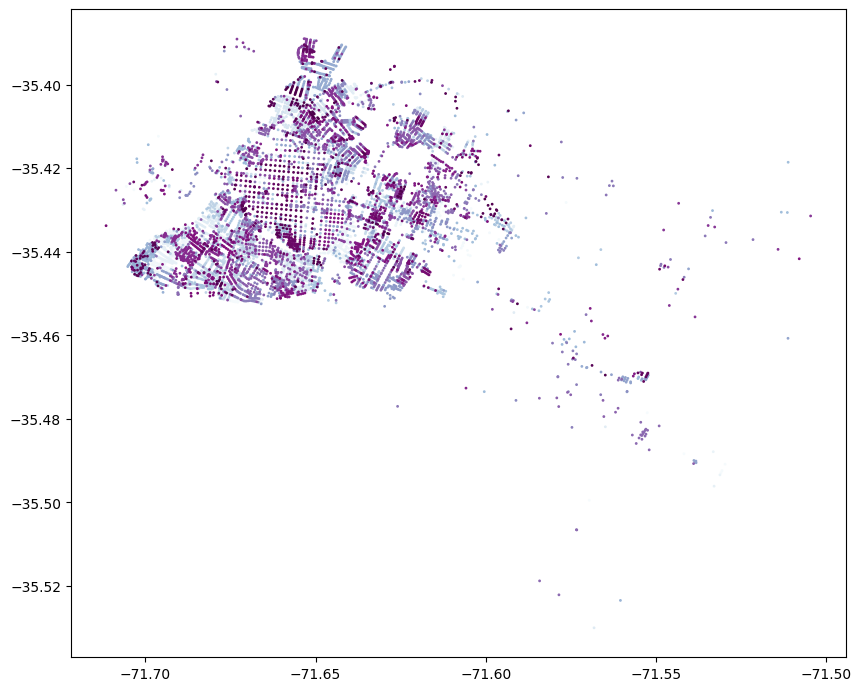

In [23]:
gdf_nodes.plot(cmap='BuPu', markersize=1, figsize=(10, 10))

In [29]:
from shapely.geometry import LineString

# Example: edges = [('688160768', '688160765', {...}), ...]
# gdf_nodes must have 'id', 'x', 'y' columns

df_edges = pd.DataFrame([
    {
        'source': u,
        'target': v,
        **data
    }
    for u, v, data in edges
])

def get_point(node_id):
    row = gdf_nodes[gdf_nodes['id'] == node_id].iloc[0]
    return (row['x'], row['y'])

df_edges['geometry'] = df_edges.apply(
    lambda row: LineString([get_point(row['source']), get_point(row['target'])]), axis=1
)

gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")

gdf_edges.head()

,source,target,length,lanes,osmid,oneway,highway,name,geometry,width,maxspeed,junction,ref,service,bridge,access,tunnel
0,688160768,688160765,40.574,2,110462466,False,residential,Calle 17 Norte,"LINESTRING (-71.65002 -35.40835, -71.64973 -35...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,688160768,688160766,74.217,1,54670058,False,residential,Pasaje 8 Oriente B,"LINESTRING (-71.65002 -35.40835, -71.64940 -35...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,688160768,685043965,37.381,2,110462466,False,residential,Calle 17 Norte,"LINESTRING (-71.65002 -35.40835, -71.65030 -35...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,688160769,688160770,37.977,1,54674731,False,living_street,17½ Norte,"LINESTRING (-71.64968 -35.40765, -71.64997 -35...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,688160769,685043965,74.859,1,54670059,False,residential,Pasaje 7½ Oriente B,"LINESTRING (-71.64968 -35.40765, -71.65030 -35...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

<Figure size 1000x1000 with 0 Axes>

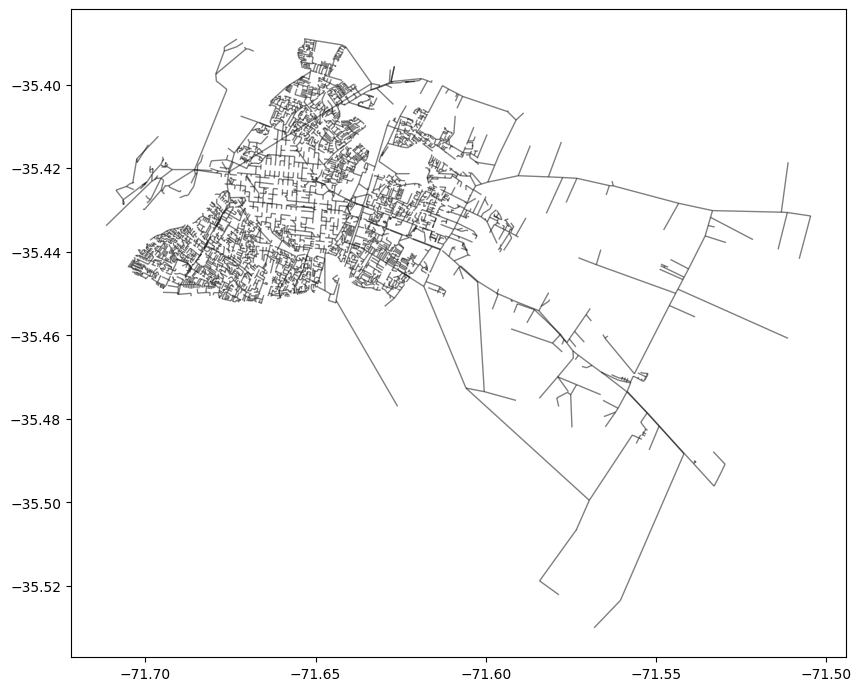

In [41]:
plt.figure(figsize=(10, 10))
gdf_edges.plot( color='black', linewidth=1, alpha=0.5,cmap='BuPu', figsize=(10, 10))

In [ ]:
tree=nx.minimum_spanning_tree(G_talca.to_undirected(),algorithm='kruskal')

<h2>Ejercicio</h2>

Se desea construir un acueducto que una las ciudades de la region del Maule. El costo en distancia se encuentra en mm en un archivo csv.

In [ ]:
import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/sherna90/matematicas_discretas/master/data/distancias_maule.csv', encoding = 'utf-8',dtype={'WKT':str,'InputID':str,'TargetID':str,'Distance':float}) 

df.loc[df['InputID']=='TALCA'].head()

,WKT,InputID,TargetID,Distance
0,"MULTIPOINT ((-71.661999 -35.432349),(-71.59687...",TALCA,PANGUILEMO,9402.992976
1,"MULTIPOINT ((-71.661999 -35.432349),(-71.56431...",TALCA,HUILQUILEMU,9026.792210
2,"MULTIPOINT ((-72.412391 -35.335426),(-71.66199...",TALCA,CONSTITUCION,69023.063640
3,"MULTIPOINT ((-72.333641 -35.427048),(-71.66199...",TALCA,SANTA OLGA,60993.437978
4,"MULTIPOINT ((-72.494926 -35.469452),(-71.66199...",TALCA,LOS PELLINES,75728.660537


In [ ]:
df['WKT'] = df['WKT'].apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))
df['InputID'] = df['InputID'].apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))
df['TargetID'] = df['TargetID'].apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))
df['InputID'].unique()

array(['TALCA', 'PANGUILEMO', 'HUILQUILEMU', 'CONSTITUCION', 'SANTA OLGA',
       'LOS PELLINES', 'CUREPTO', 'EMPEDRADO', 'MAULE', 'CULENAR',
       'VILLA FRANCIA', 'CHACARILLAS', 'PELARCO', 'PENCAHUE', 'CUMPEO',
       'SAN CLEMENTE', 'SAN RAFAEL', 'CAUQUENES', 'CHANCO', 'PELLUHUE',
       'QUILICURA', 'CURICO', 'SARMIENTO', 'VILLA LOS NICHES',
       'SAN ALBERTO', 'HUALAE', 'LICANTEN', 'ILOCA', 'MOLINA',
       'ITAHUE UNO', 'RAUCO', 'ROMERAL', 'SAGRADA  FAMILIA', 'VILLA PRAT',
       'TENO', 'LLICO', 'LAGO VICHUQUEN', 'LINARES', 'VARA GRUESA',
       'LAS OBRAS', 'COLBUN', 'PANIMAVIDA', 'LONGAVI', 'PARRAL', 'RETIRO',
       'COPIHUE', 'SAN JAVIER', 'BOBADILLA', 'VILLA ALEGRE',
       'YERBAS BUENAS'], dtype=object)

In [ ]:
import numpy as np
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r *1000
